**Task 2:- Perform data cleaning and exploratory data analysis (EDA) on a dataset of your choice, such as the Titanic dataset from Kaggle. Explore the relationships between variables and identify patterns and trends in the data.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("C:\\Users\\Simarjeet kaur\\OneDrive\\Desktop\DS prodigy Infotech\\train.csv")

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [24]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

We can see that age has 177 null values

We can Impute missing values in the "Age" column

Also there are some missing values in the "Embarked" column, we'll drop these values, and also they are relatively few.

In [8]:
df["Age"].fillna(df["Age"].median(),inplace=True)

In [9]:
df["Age"]

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [10]:
df["Embarked"].dropna(inplace=True)

In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Exploring relationships between variables using correlation analysis

In [15]:
corr_mat=df.corr()

In [16]:
corr_mat

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


In [17]:
print(corr_mat)

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.034212 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.064910 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.339898  0.083081  0.018443   
Age             0.034212 -0.064910 -0.339898  1.000000 -0.233296 -0.172482   
SibSp          -0.057527 -0.035322  0.083081 -0.233296  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.172482  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096688  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096688  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


**Bar chart to visualise the distribution of survivors by class using matplotlib and seaborn libraries**

Text(0.5, 1.0, 'Survival count by Class')

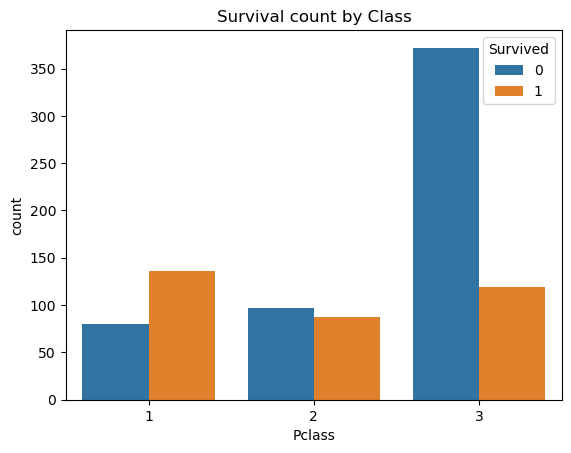

In [29]:
sns.countplot(x="Pclass",hue="Survived",data=df)
plt.title("Survival count by Class")

This shows us that passengers in first class had a slightly higher chance of surviving compared to those in second and third class. Most third-class passengers did not survive, while the survival rate for second-class passengers was somewhere in between.

This means that being in first class offered a better chance of survival, second class had a moderate chance, and third-class passengers were the least likely to survive.

**Bar chart to visualise the distribution of survivors by sex using matplotlib and seaborn libraries**

Text(0.5, 1.0, 'Survival count by Sex')

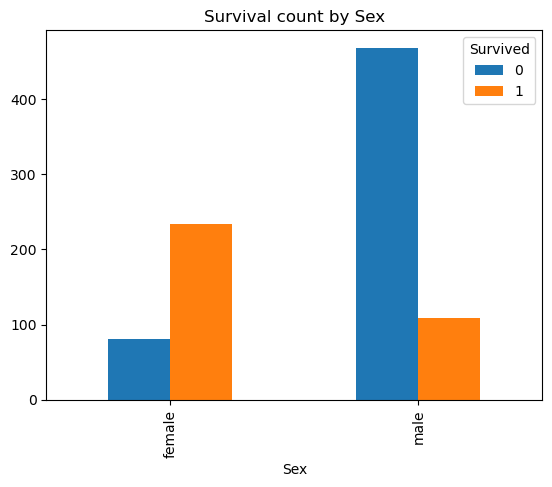

In [37]:
pd.crosstab(df["Sex"],df["Survived"]).plot(kind="bar")
plt.title("Survival count by Sex")

Based on the data or chart, a larger number of women survived compared to men. The pattern or trend suggests that survival rates were higher for females than for males.

**Scatter Plot to visualise the relationship between "Age" and "Survived" using matplotlib and seaborn**

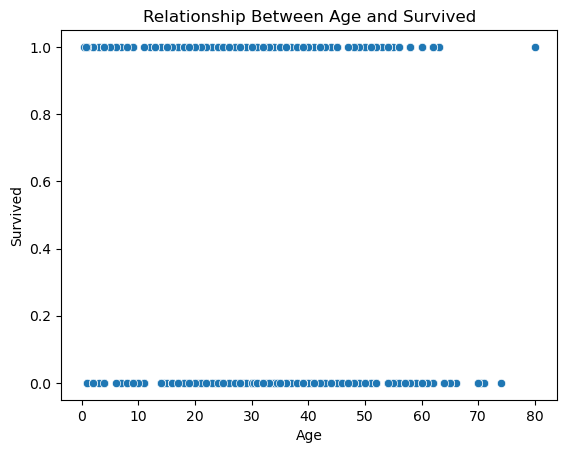

In [38]:
sns.scatterplot(x="Age",y="Survived",data=df)
plt.title("Relationship Between Age and Survived")
plt.show()

There might be some patterns regarding survival for children (especially those below 10), who seem to have a relatively higher chance of survival.

For older age groups, the plot shows survival is less predictable, and both survival and non-survival outcomes occur at various ages.

### Visualizing Correlation Matrix

<Axes: >

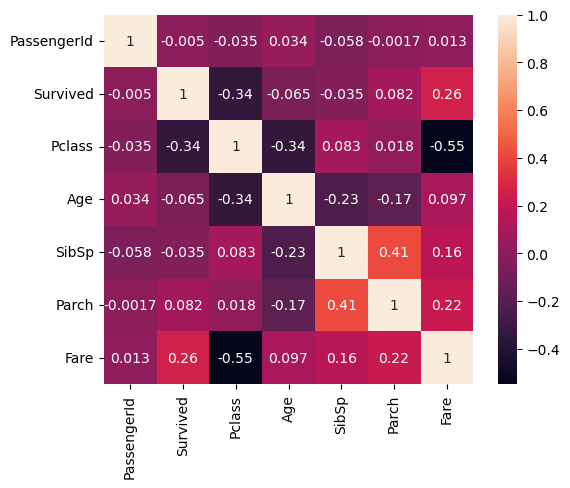

In [39]:
sns.heatmap(corr_mat, annot=True ,square=True)

**KEY INSIGHTS**

**Survived and Pclass**- There is a negative correlation (-0.34) between Survived and Pclass, which means that passengers in higher class (1st Class) were most likely to survive, while those lower class had lower survival rates

**Survived and Fare**- There's a moderate positive correlation (0.26) between Survived and Fare, indicating that passengers who paid higher fares had a better chance of survival, which aligns with the class-based survival trend.

**Pclass and Fare**- A strong negative correlation (-0.55) exists between Pclass and Fare. This means that lower-class passengers paid less for their tickets, while first-class passengers paid significantly higher fares.

**SibSp and Parch**- There's a positive correlation (0.41) between SibSp (number of siblings/spouses aboard) and Parch (number of parents/children aboard), indicating that passengers with siblings or spouses aboard were also more likely to have parents or children aboard.

**Age and Class**- There's a negative correlation (-0.34) between Age and Pclass, suggesting that younger passengers were more likely to be in lower classes, while older passengers were more often in first class.

In [40]:
import jovian

In [42]:
jovian.commit(project="Task 2")

<IPython.core.display.Javascript object>

[jovian] Updating notebook "simarjeetk927/task-2" on https://jovian.com/
[jovian] Committed successfully! https://jovian.com/simarjeetk927/task-2


'https://jovian.com/simarjeetk927/task-2'